### Import necessary libraries for data processing, visualization, machine learning, and model evaluation
#### This cell loads all required Python libraries including pandas, matplotlib, scikit-learn, SHAP, and XGBoost.


In [1]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import shap
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
# pip install xgboost

###  Define S3 bucket and file key for data retrieval
Specify the Amazon S3 bucket name and the CSV file key to access the dataset.


In [3]:
bucket_name = 'midterm-project-01'
file_key = 'sample_df_aws.csv'

###  Load dataset from S3 into a Pandas DataFrame
Use the boto3 client to read the CSV file from S3 and load it into a DataFrame for analysis.


In [4]:
# Create an S3 client
s3 = boto3.client('s3')

# Generate a presigned URL or use S3 object directly
obj = s3.get_object(Bucket=bucket_name, Key=file_key)

# Read the CSV data into a Pandas DataFrame
df = pd.read_csv(obj['Body'])

# Show the first few rows
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,file_year,file_month,airport_fee,PU_Borough,PU_Zone,DO_Borough,DO_Zone,Pickup_Point,Dropoff_Point,season
0,2,2022-11-02 14:15:20,2022-11-02 15:03:41,1.0,11.37,1.0,N,70,230,1,...,2022,11,1.25,Queens,East Elmhurst,Manhattan,Times Sq/Theatre District,"Queens, East Elmhurst","Manhattan, Times Sq/Theatre District",Fall
1,2,2022-10-15 13:02:51,2022-10-15 13:21:32,1.0,2.91,1.0,N,75,161,1,...,2022,10,0.00,Manhattan,East Harlem South,Manhattan,Midtown Center,"Manhattan, East Harlem South","Manhattan, Midtown Center",Fall
2,2,2022-02-04 12:46:20,2022-02-04 12:52:00,1.0,0.88,1.0,N,238,151,1,...,2022,2,0.00,Manhattan,Upper West Side North,Manhattan,Manhattan Valley,"Manhattan, Upper West Side North","Manhattan, Manhattan Valley",Winter
3,2,2022-08-31 23:39:25,2022-08-31 23:44:15,1.0,1.44,1.0,N,140,262,1,...,2022,8,0.00,Manhattan,Lenox Hill East,Manhattan,Yorkville East,"Manhattan, Lenox Hill East","Manhattan, Yorkville East",Summer
4,1,2022-01-25 13:29:29,2022-01-25 13:41:53,1.0,1.70,1.0,N,142,140,1,...,2022,1,0.00,Manhattan,Lincoln Square East,Manhattan,Lenox Hill East,"Manhattan, Lincoln Square East","Manhattan, Lenox Hill East",Winter


### EDA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199988 entries, 0 to 1199987
Data columns (total 35 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   VendorID               1199988 non-null  int64  
 1   tpep_pickup_datetime   1199988 non-null  object 
 2   tpep_dropoff_datetime  1199988 non-null  object 
 3   passenger_count        1199988 non-null  float64
 4   trip_distance          1199988 non-null  float64
 5   RatecodeID             1199988 non-null  float64
 6   store_and_fwd_flag     1199988 non-null  object 
 7   PULocationID           1199988 non-null  int64  
 8   DOLocationID           1199988 non-null  int64  
 9   payment_type           1199988 non-null  int64  
 10  fare_amount            1199988 non-null  float64
 11  extra                  1199988 non-null  float64
 12  mta_tax                1199988 non-null  float64
 13  tip_amount             1199988 non-null  float64
 14  tolls_amount      

In [6]:
df.shape

(1199988, 35)

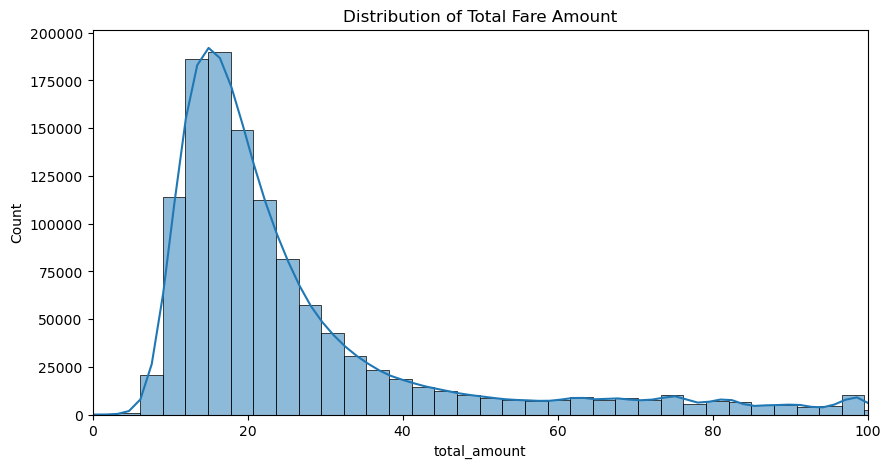

In [7]:
plt.figure(figsize=(10,5))
sns.histplot(df['total_amount'], bins=100, kde=True)
plt.title('Distribution of Total Fare Amount')
plt.xlim(0, 100)
plt.show()

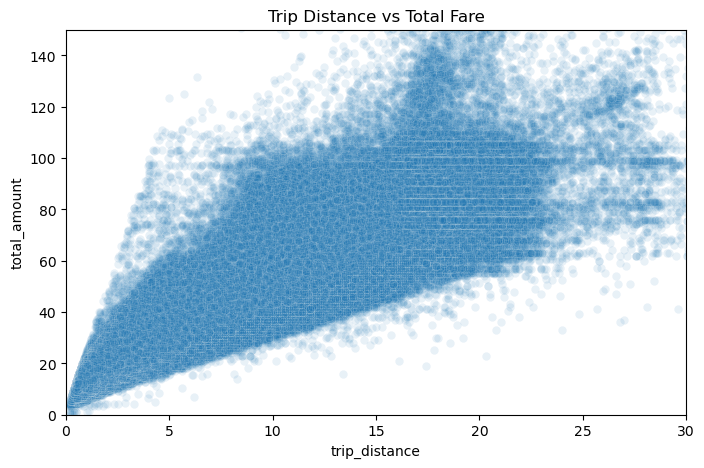

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='trip_distance', y='total_amount', data=df, alpha=0.1)
plt.title('Trip Distance vs Total Fare')
plt.xlim(0, 30)
plt.ylim(0, 150)
plt.show()

/tmp/ipykernel_29219/1418641264.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


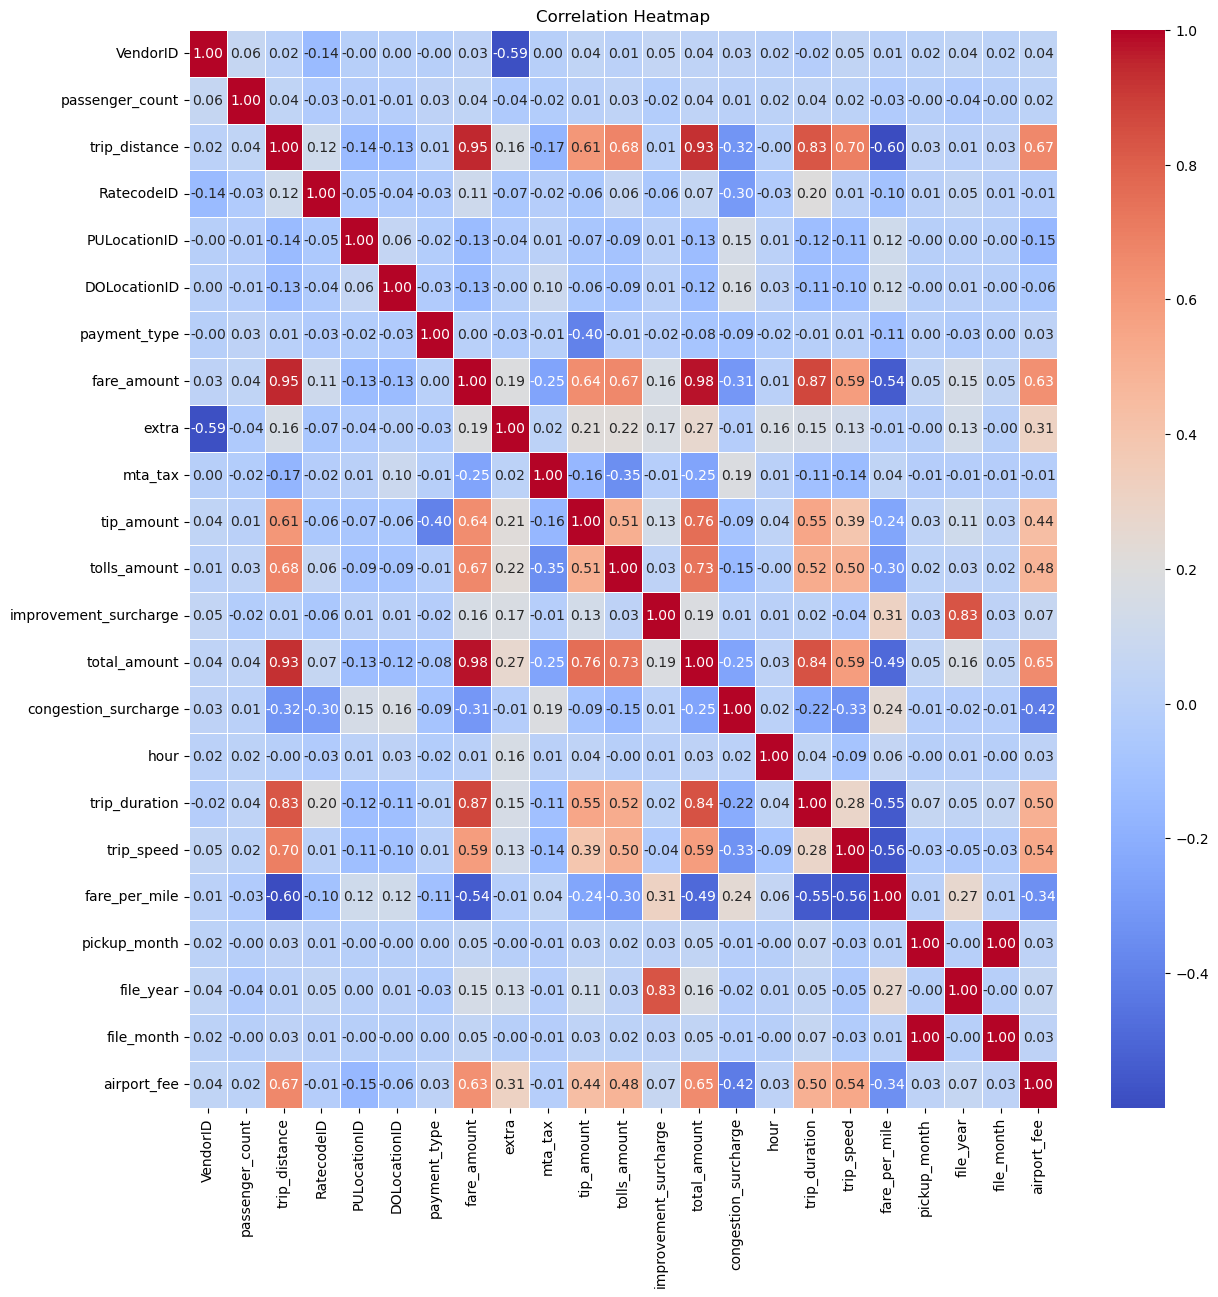

In [9]:
plt.figure(figsize=(14, 14))

correlation_matrix = df.corr() 

# Generate a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Display the plot
plt.title('Correlation Heatmap')
plt.show()

#### 1) fare_amount, mta_tax, tip_amount, tolls_amount,improvement_surcharge, congestion_surcharge, airport_fee, extra --> 
##### These columns are literally components of total_amount (they sum to it). Including them will give you an almost perfect fit—but it isn’t real forecasting; it’s just arithmetic. Our goal is genuinely to predict from trip characteristics, so we omit those breakdown columns.

#### 2)Highly Collinear columns
##### trip_distance, trip_duration, and derived trip_speed are tightly linked.


In [10]:
# Select features for modeling
features = [
    'trip_distance', 
    'passenger_count', 
    'trip_duration', 
    # 'trip_speed', 
    'fare_per_mile',
    'hour', 
    'pickup_day', 
    'pickup_month', 
    'RatecodeID', 
    'payment_type',
    #'mta_tax', 
    #'tip_amount', 
    #'tolls_amount', 
    #'improvement_surcharge', 
    #'congestion_surcharge', 
    #'airport_fee',
    'VendorID' , 
    'PULocationID', 
    'DOLocationID', 
    #'extra', 
    #'fare_amount', 
    'time_slot', 
    'season'
]
target = 'total_amount'

In [11]:
# Subset the DataFrame
selected_columns = features + [target]
new_df = df[selected_columns].copy()

# Quick check
print(new_df.shape)
new_df.head()


(1199988, 15)


,trip_distance,passenger_count,trip_duration,fare_per_mile,hour,pickup_day,pickup_month,RatecodeID,payment_type,VendorID,PULocationID,DOLocationID,time_slot,season,total_amount
0,11.37,1.0,48.350000,5.445910,15,Wednesday,11,1.0,1,2,70,230,Afternoon,Fall,61.92
1,2.91,1.0,18.683333,7.134021,13,Saturday,10,1.0,1,2,75,161,Afternoon,Fall,20.76
2,0.88,1.0,5.666667,13.409091,12,Friday,2,1.0,1,2,238,151,Afternoon,Winter,11.80
3,1.44,1.0,4.833333,7.638889,23,Wednesday,8,1.0,1,2,140,262,Night,Summer,11.00
4,1.70,1.0,12.400000,9.764706,13,Tuesday,1,1.0,1,1,142,140,Afternoon,Winter,16.60


#### Encoding


##### One-Hot Encoding

In [12]:
def one_hot_encode(df: pd.DataFrame, column: str, drop_first: bool = False) -> pd.DataFrame:
    """
    One-hot encode the specified column in-place (or can assign the result to a new DataFrame).

    Parameters:
    - df: DataFrame containing the column to encode.
    - column: Name of the categorical column to one-hot encode.
    - drop_first: If True, drops the first level to avoid multicollinearity (useful for linear models).

    Returns:
    - A new DataFrame with the original column replaced by its one-hot encoded dummy columns.
    """
    return pd.get_dummies(
        df,
        columns=[column],
        prefix=column,
        drop_first=drop_first,
        dtype=int
    )

In [13]:
df_encoded = one_hot_encode(new_df, 'season', drop_first=True)

In [14]:
df_encoded

,trip_distance,passenger_count,trip_duration,fare_per_mile,hour,pickup_day,pickup_month,RatecodeID,payment_type,VendorID,PULocationID,DOLocationID,time_slot,total_amount,season_Spring,season_Summer,season_Winter
0,11.37,1.0,48.350000,5.445910,15,Wednesday,11,1.0,1,2,70,230,Afternoon,61.92,0,0,0
1,2.91,1.0,18.683333,7.134021,13,Saturday,10,1.0,1,2,75,161,Afternoon,20.76,0,0,0
2,0.88,1.0,5.666667,13.409091,12,Friday,2,1.0,1,2,238,151,Afternoon,11.80,0,0,1
3,1.44,1.0,4.833333,7.638889,23,Wednesday,8,1.0,1,2,140,262,Night,11.00,0,1,0
4,1.70,1.0,12.400000,9.764706,13,Tuesday,1,1.0,1,1,142,140,Afternoon,16.60,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199983,0.46,3.0,2.383333,22.739130,10,Saturday,11,1.0,1,2,236,236,Morning,10.46,0,0,0
1199984,2.94,2.0,17.950000,9.836735,0,Saturday,6,1.0,1,2,107,262,Night,28.92,0,1,0
1199985,19.50,1.0,31.916667,4.935385,0,Sunday,11,2.0,1,1,132,151,Night,96.24,0,0,0
1199986,2.52,1.0,15.416667,11.400794,19,Wednesday,3,1.0,1,2,263,137,Evening,28.73,1,0,0


### Define a function to apply cyclical encoding to periodic features
Create a reusable function to encode features like hour, day, or month into sine and cosine components for machine learning models.


In [15]:
def cyclical_encode(df, column, period, prefix=None, drop_original=False):
    """
    Applies cyclical encoding to a numeric column.
    
    Parameters:
    - df: pandas DataFrame containing the column.
    - column: str, name of the column to encode (values 0..period-1).
    - period: int, the cycle length (e.g., 24 for hours, 7 for days, 12 for months).
    - prefix: str or None, base for new column names; defaults to column name.
    - drop_original: bool, if True, drops the original column after encoding.
    
    Returns:
    - df: DataFrame with two new columns: <prefix>_sin and <prefix>_cos.
    """    
    name = prefix if prefix else column
    values = df[column].astype(float)
    
    df[f"{name}_sin"] = np.sin(2 * np.pi * values / period)
    df[f"{name}_cos"] = np.cos(2 * np.pi * values / period)
    
    if drop_original:
        df.drop(columns=[column], inplace=True)
    
    return df

In [16]:
df_encoded = cyclical_encode(df_encoded, 'hour', period=24, prefix='hour', drop_original=False)


In [17]:
df_encoded

,trip_distance,passenger_count,trip_duration,fare_per_mile,hour,pickup_day,pickup_month,RatecodeID,payment_type,VendorID,PULocationID,DOLocationID,time_slot,total_amount,season_Spring,season_Summer,season_Winter,hour_sin,hour_cos
0,11.37,1.0,48.350000,5.445910,15,Wednesday,11,1.0,1,2,70,230,Afternoon,61.92,0,0,0,-7.071068e-01,-0.707107
1,2.91,1.0,18.683333,7.134021,13,Saturday,10,1.0,1,2,75,161,Afternoon,20.76,0,0,0,-2.588190e-01,-0.965926
2,0.88,1.0,5.666667,13.409091,12,Friday,2,1.0,1,2,238,151,Afternoon,11.80,0,0,1,1.224647e-16,-1.000000
3,1.44,1.0,4.833333,7.638889,23,Wednesday,8,1.0,1,2,140,262,Night,11.00,0,1,0,-2.588190e-01,0.965926
4,1.70,1.0,12.400000,9.764706,13,Tuesday,1,1.0,1,1,142,140,Afternoon,16.60,0,0,1,-2.588190e-01,-0.965926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199983,0.46,3.0,2.383333,22.739130,10,Saturday,11,1.0,1,2,236,236,Morning,10.46,0,0,0,5.000000e-01,-0.866025
1199984,2.94,2.0,17.950000,9.836735,0,Saturday,6,1.0,1,2,107,262,Night,28.92,0,1,0,0.000000e+00,1.000000
1199985,19.50,1.0,31.916667,4.935385,0,Sunday,11,2.0,1,1,132,151,Night,96.24,0,0,0,0.000000e+00,1.000000
1199986,2.52,1.0,15.416667,11.400794,19,Wednesday,3,1.0,1,2,263,137,Evening,28.73,1,0,0,-9.659258e-01,0.258819


#### Encode Pickupup_Day 

In [18]:
day_map = {
    'Monday':    0,
    'Tuesday':   1,
    'Wednesday': 2,
    'Thursday':  3,
    'Friday':    4,
    'Saturday':  5,
    'Sunday':    6
}
df_encoded['pickup_day_idx'] = df['pickup_day'].map(day_map)

# 2) now apply cyclical encoder
df_encoded = cyclical_encode( df_encoded, column='pickup_day_idx', period=7, prefix='pickup_day', drop_original=True )

In [19]:
df_encoded

,trip_distance,passenger_count,trip_duration,fare_per_mile,hour,pickup_day,pickup_month,RatecodeID,payment_type,VendorID,...,DOLocationID,time_slot,total_amount,season_Spring,season_Summer,season_Winter,hour_sin,hour_cos,pickup_day_sin,pickup_day_cos
0,11.37,1.0,48.350000,5.445910,15,Wednesday,11,1.0,1,2,...,230,Afternoon,61.92,0,0,0,-7.071068e-01,-0.707107,0.974928,-0.222521
1,2.91,1.0,18.683333,7.134021,13,Saturday,10,1.0,1,2,...,161,Afternoon,20.76,0,0,0,-2.588190e-01,-0.965926,-0.974928,-0.222521
2,0.88,1.0,5.666667,13.409091,12,Friday,2,1.0,1,2,...,151,Afternoon,11.80,0,0,1,1.224647e-16,-1.000000,-0.433884,-0.900969
3,1.44,1.0,4.833333,7.638889,23,Wednesday,8,1.0,1,2,...,262,Night,11.00,0,1,0,-2.588190e-01,0.965926,0.974928,-0.222521
4,1.70,1.0,12.400000,9.764706,13,Tuesday,1,1.0,1,1,...,140,Afternoon,16.60,0,0,1,-2.588190e-01,-0.965926,0.781831,0.623490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199983,0.46,3.0,2.383333,22.739130,10,Saturday,11,1.0,1,2,...,236,Morning,10.46,0,0,0,5.000000e-01,-0.866025,-0.974928,-0.222521
1199984,2.94,2.0,17.950000,9.836735,0,Saturday,6,1.0,1,2,...,262,Night,28.92,0,1,0,0.000000e+00,1.000000,-0.974928,-0.222521
1199985,19.50,1.0,31.916667,4.935385,0,Sunday,11,2.0,1,1,...,151,Night,96.24,0,0,0,0.000000e+00,1.000000,-0.781831,0.623490
1199986,2.52,1.0,15.416667,11.400794,19,Wednesday,3,1.0,1,2,...,137,Evening,28.73,1,0,0,-9.659258e-01,0.258819,0.974928,-0.222521


In [20]:
# Drop every column as well
df_encoded.drop(columns='hour', inplace=True)

In [21]:
df_encoded.drop(columns='pickup_day', inplace=True)

#### Encode pickup_month

In [22]:
df_encoded = cyclical_encode( df_encoded, column='pickup_month',  period=12,  prefix='pickup_month',  drop_original=True)


#### Encode time_slot

In [23]:
df_encoded = one_hot_encode(df_encoded, column='time_slot', drop_first=True)

In [24]:
df_encoded.columns

Index(['trip_distance', 'passenger_count', 'trip_duration', 'fare_per_mile',
       'RatecodeID', 'payment_type', 'VendorID', 'PULocationID',
       'DOLocationID', 'total_amount', 'season_Spring', 'season_Summer',
       'season_Winter', 'hour_sin', 'hour_cos', 'pickup_day_sin',
       'pickup_day_cos', 'pickup_month_sin', 'pickup_month_cos',
       'time_slot_Evening', 'time_slot_Morning', 'time_slot_Night'],
      dtype='object')

In [25]:
df_encoded

,trip_distance,passenger_count,trip_duration,fare_per_mile,RatecodeID,payment_type,VendorID,PULocationID,DOLocationID,total_amount,...,season_Winter,hour_sin,hour_cos,pickup_day_sin,pickup_day_cos,pickup_month_sin,pickup_month_cos,time_slot_Evening,time_slot_Morning,time_slot_Night
0,11.37,1.0,48.350000,5.445910,1.0,1,2,70,230,61.92,...,0,-7.071068e-01,-0.707107,0.974928,-0.222521,-5.000000e-01,8.660254e-01,0,0,0
1,2.91,1.0,18.683333,7.134021,1.0,1,2,75,161,20.76,...,0,-2.588190e-01,-0.965926,-0.974928,-0.222521,-8.660254e-01,5.000000e-01,0,0,0
2,0.88,1.0,5.666667,13.409091,1.0,1,2,238,151,11.80,...,1,1.224647e-16,-1.000000,-0.433884,-0.900969,8.660254e-01,5.000000e-01,0,0,0
3,1.44,1.0,4.833333,7.638889,1.0,1,2,140,262,11.00,...,0,-2.588190e-01,0.965926,0.974928,-0.222521,-8.660254e-01,-5.000000e-01,0,0,1
4,1.70,1.0,12.400000,9.764706,1.0,1,1,142,140,16.60,...,1,-2.588190e-01,-0.965926,0.781831,0.623490,5.000000e-01,8.660254e-01,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199983,0.46,3.0,2.383333,22.739130,1.0,1,2,236,236,10.46,...,0,5.000000e-01,-0.866025,-0.974928,-0.222521,-5.000000e-01,8.660254e-01,0,1,0
1199984,2.94,2.0,17.950000,9.836735,1.0,1,2,107,262,28.92,...,0,0.000000e+00,1.000000,-0.974928,-0.222521,1.224647e-16,-1.000000e+00,0,0,1
1199985,19.50,1.0,31.916667,4.935385,2.0,1,1,132,151,96.24,...,0,0.000000e+00,1.000000,-0.781831,0.623490,-5.000000e-01,8.660254e-01,0,0,1
1199986,2.52,1.0,15.416667,11.400794,1.0,1,2,263,137,28.73,...,0,-9.659258e-01,0.258819,0.974928,-0.222521,1.000000e+00,6.123234e-17,1,0,0


#### Scaling

In [26]:
continuous_cols = [
    'trip_distance',
    'passenger_count',
    'trip_duration',
    'fare_per_mile'
]

In [27]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on those columns and transform in place
df_encoded[continuous_cols] = scaler.fit_transform(df_encoded[continuous_cols])

In [28]:
df_encoded

,trip_distance,passenger_count,trip_duration,fare_per_mile,RatecodeID,payment_type,VendorID,PULocationID,DOLocationID,total_amount,...,season_Winter,hour_sin,hour_cos,pickup_day_sin,pickup_day_cos,pickup_month_sin,pickup_month_cos,time_slot_Evening,time_slot_Morning,time_slot_Night
0,1.723524,-0.442066,2.402562,-1.143207,1.0,1,2,70,230,61.92,...,0,-7.071068e-01,-0.707107,0.974928,-0.222521,-5.000000e-01,8.660254e-01,0,0,0
1,-0.170899,-0.442066,0.170446,-0.762106,1.0,1,2,75,161,20.76,...,0,-2.588190e-01,-0.965926,-0.974928,-0.222521,-8.660254e-01,5.000000e-01,0,0,0
2,-0.625471,-0.442066,-0.808927,0.654532,1.0,1,2,238,151,11.80,...,1,1.224647e-16,-1.000000,-0.433884,-0.900969,8.660254e-01,5.000000e-01,0,0,0
3,-0.500072,-0.442066,-0.871627,-0.648128,1.0,1,2,140,262,11.00,...,0,-2.588190e-01,0.965926,0.974928,-0.222521,-8.660254e-01,-5.000000e-01,0,0,1
4,-0.441851,-0.442066,-0.302312,-0.168211,1.0,1,1,142,140,16.60,...,1,-2.588190e-01,-0.965926,0.781831,0.623490,5.000000e-01,8.660254e-01,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1199983,-0.719520,1.815155,-1.055964,2.760849,1.0,1,2,236,236,10.46,...,0,5.000000e-01,-0.866025,-0.974928,-0.222521,-5.000000e-01,8.660254e-01,0,1,0
1199984,-0.164181,0.686544,0.115270,-0.151950,1.0,1,2,107,262,28.92,...,0,0.000000e+00,1.000000,-0.974928,-0.222521,1.224647e-16,-1.000000e+00,0,0,1
1199985,3.544051,-0.442066,1.166120,-1.258462,2.0,1,1,132,151,96.24,...,0,0.000000e+00,1.000000,-0.781831,0.623490,-5.000000e-01,8.660254e-01,0,0,1
1199986,-0.258231,-0.442066,-0.075338,0.201146,1.0,1,2,263,137,28.73,...,0,-9.659258e-01,0.258819,0.974928,-0.222521,1.000000e+00,6.123234e-17,1,0,0


### Split the dataset into training and testing sets
Separate features and target variable, then split the data into 80% training and 20% testing to prepare for model training and evaluation.


In [29]:
# 1. Separate features and target

X = df_encoded.drop(columns=['total_amount'])
y = df_encoded['total_amount']

In [30]:
# 2. Split into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% hold-out for testing
    random_state=42      # for reproducibility
)


In [31]:
# Quick sanity check

print("X_train:", X_train.shape)
print("X_test:",  X_test.shape)
print("y_train:", y_train.shape)
print("y_test:",  y_test.shape)

X_train: (959990, 21)
X_test: (239998, 21)
y_train: (959990,)
y_test: (239998,)


### Train a Linear Regression model and evaluate its performance
Fit a Linear Regression model on the training data, make predictions, and compute evaluation metrics (R², MSE, MAE) on the test set.


In [32]:
# 1. Instantiate and train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# 2. Predict on the test set
y_pred = lr.predict(X_test)

# 3. Compute metrics
r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# 4. Print results
print(f"R²:  {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

R²:  0.8996
MSE: 42.5559
MAE: 3.7628


##### Our model explains about 90% of the variance in total_amount. That’s very strong for a linear model on real‐world taxi data.
##### MAE ≈ 3.76 means on average fare predictions are off by about $3.80. RMSE ≈ √42.56 ≈ $6.52 tells you that larger errors (outliers) are driving up the squared error more—so a handful of trips with big surcharges or tips are pulling the RMSE higher.

#### 5-Fold Cross Validation

In [33]:
# 2. Initialize model
model = LinearRegression()

# 3. Define the scoring metrics
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'R2': 'r2'
}

# 4. Run 5-fold cross-validation
cv_results = cross_validate(
    model,
    X,
    y,
    scoring=scoring,
    cv=5,
    return_train_score=False
)

# 2) Fold‐wise summary in a DataFrame
cv_df = pd.DataFrame({
    'MAE':  -cv_results['test_MAE'],
    'MSE':  -cv_results['test_MSE'],
    'RMSE': np.sqrt(-cv_results['test_MSE']),
    'R2':   cv_results['test_R2']
})

cv_df.index = [f"Fold {i+1}" for i in cv_df.index]
print("\nFold-wise performance:")
print(cv_df)


Fold-wise performance:
             MAE        MSE      RMSE        R2
Fold 1  5.375880  63.553703  7.972058  0.744954
Fold 2  4.208684  47.347579  6.880958  0.861205
Fold 3  3.718444  41.343148  6.429864  0.914637
Fold 4  3.846383  45.356287  6.734708  0.907540
Fold 5  3.923296  48.260052  6.946946  0.903449


#### Fold 1 is notably weaker (R² ~0.75, MAE ~5.4)—this suggests that particular slice of data (perhaps a time period or region) has different patterns (e.g. more extreme fares, different surcharge structure).

### Visualize Linear Regression model performance
Plot Predicted vs. Actual fares and Residuals vs. Fitted values to assess model accuracy and diagnose potential biases or patterns in residuals.


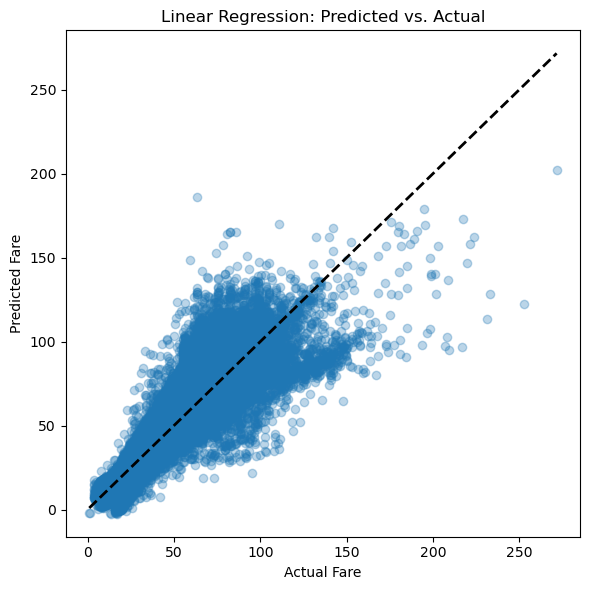

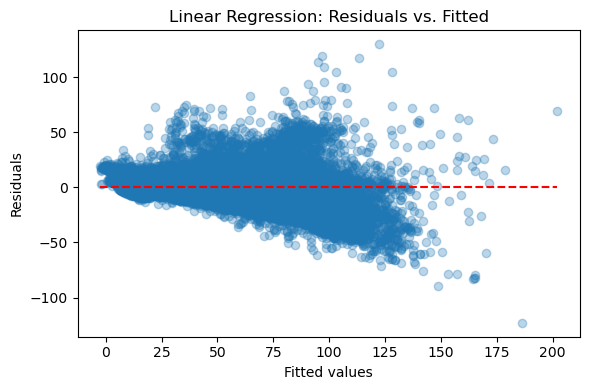

In [34]:
_pred_lr    = lr.predict(X_test)
residuals_lr = y_test - y_pred

# 2. Predicted vs. Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--', linewidth=2
)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Linear Regression: Predicted vs. Actual")
plt.tight_layout()
plt.show()

# 3. Residuals vs. Fitted
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals_lr, alpha=0.3)
plt.hlines(
    0,
    y_pred.min(),
    y_pred.max(),
    colors='r',
    linestyles='dashed'
)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residuals vs. Fitted")
plt.tight_layout()
plt.show()

#### A “funnel” shape—residuals’ spread (distance from zero) increases as predicted fare goes up.
####  At high predicted values the residuals skew more negative (you’re under-predicting expensive trips), while at mid-range you have more positive residuals.

#### Training with all the features as of now and will check the SHAP values to take the important features

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


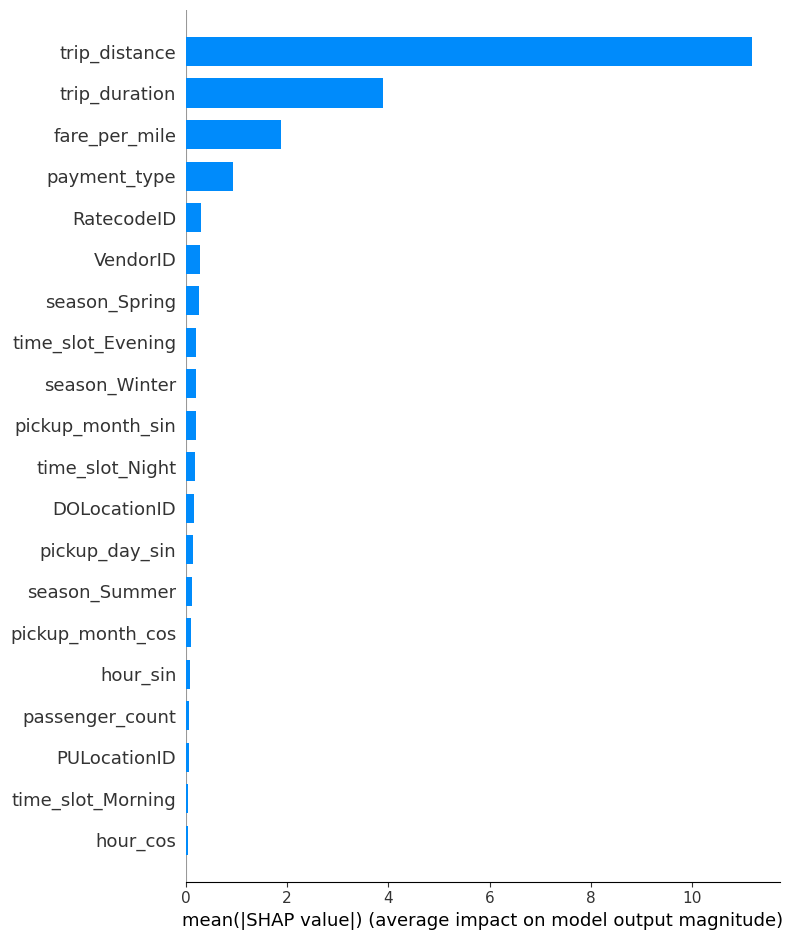

In [35]:
# 1. Create a SHAP explainer for a linear model
explainer = shap.LinearExplainer(
    lr,                    # trained LinearRegression
    X_train,               # background dataset
    feature_perturbation="interventional"  # recommended for linear models
)

# 2. Calculate SHAP values on the test set
shap_values = explainer.shap_values(X_test)

# 3. Summary plot (global feature importance)
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar",       # bar chart of mean(|SHAP|)
    feature_names=X_test.columns
)

#### Trip distance is by far the biggest driver - variations in distance move prediction the most.
#### Trip duration & fare_per_mile come next - longer or slower trips cost more, and a higher per-mile rate directly bumps up the fare.
#### Small but non-zero impact from categorical/time features
#### Almost zero contribution from cyclical/time/location encodings


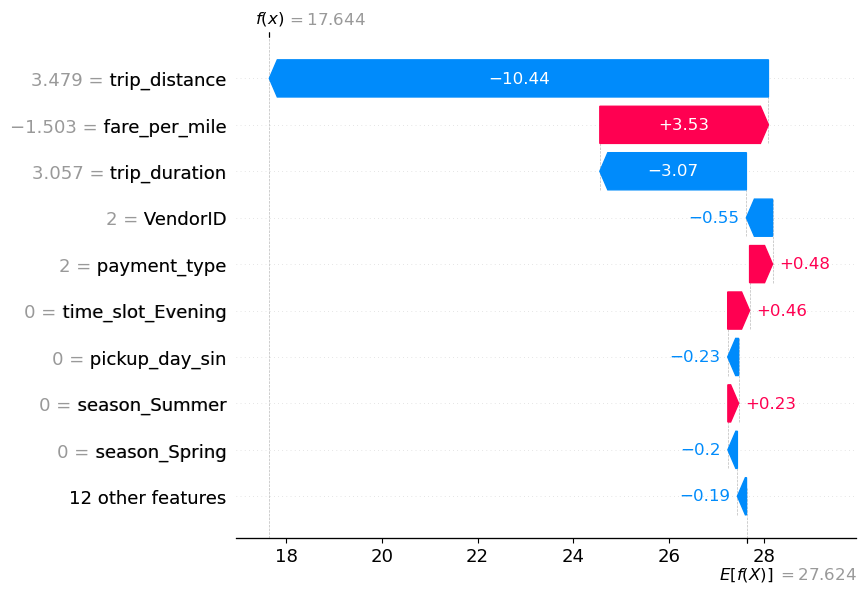

In [36]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[1],
        feature_names=X_test.columns
    )
)


#### trip_distance (−10.44) → because this trip was shorter than average, it drags the fare down by 10.44
#### fare_per_mile (+3.53) → a relatively high per-mile rate bumps the fare up by 3.53
#### trip_duration (−3.07) → this trip was quicker than typical, knocking off another 3.07
#### VendorID (−0.55) → this particular vendor tends to charge a bit less (−0.55)
#### payment_type (+0.48) → paying by card vs. cash adds around 0.48
#### time_slot_Evening (+0.46) → evening rides are priced slightly higher, +0.46
#### pickup_day_sin (−0.23) → the day of week (encoded cyclically) subtracts 0.23
#### season_Summer (+0.23) → summer trips on average cost 0.23 more
#### season_Spring (−0.20) → spring trips 0.20 below the mean


### Instantiate a Random Forest Regressor with initial hyperparameters
Create a Random Forest model with controlled complexity and subsampling to balance accuracy and computational efficiency.


In [37]:
# 1. Instantiate a lighter, more resource-friendly forest
rf = RandomForestRegressor(
    n_estimators=50,         # half as many trees
    max_depth=20,            # cap tree depth
    max_features='sqrt',     # use √(n_features) at each split
    min_samples_leaf=5,      # require at least 5 samples at each leaf
    max_samples=0.5,         # sample 50% of rows per tree (sklearn ≥1.2)
    random_state=42,
    n_jobs=-1,               # use all cores, but with smaller trees
    verbose=1                # show progress
)

#### Out-of-Bag (OOB) Estimation is a built-in way for Random Forests to estimate generalization error without a separate validation set or cross-validation

In [38]:
# rf = RandomForestRegressor(
#     n_estimators=300,
#     max_depth=20,
#     oob_score=True,
#     n_jobs=-1,
#     random_state=42
# )
# rf.fit(X_train, y_train)
# print("OOB RMSE:", np.sqrt(mean_squared_error(y_train, rf.oob_prediction_)))


### Train the Random Forest model and evaluate its performance
Fit the Random Forest on training data, predict on the test set, and compute evaluation metrics (MAE, MSE, RMSE, R²) to assess model effectiveness.


In [39]:
# 2. Fit on the training data
rf.fit(X_train, y_train)

# 3. Predict on the test set
y_pred_rf = rf.predict(X_test)

# 4. Evaluate performance
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE:  {mae_rf:.4f}")
print(f"MSE:  {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   45.1s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   48.6s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.4s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    2.6s finished


Random Forest Performance:
MAE:  1.3014
MSE:  5.4842
RMSE: 2.3418
R²:   0.9871


#### R² = 0.987 means features explain 98.7 % of the variance in fare
#### RMSE = 2.34 tells you large errors (outliers) are still pretty small.
#### MAE = 1.30 means on average you’re only off by $1.30 per trip.

### **Grid Search**

In [ ]:
# 1. Take a random 10% sample of the original
X_sub = X.sample(frac=0.05, random_state=42)
y_sub = y.loc[X_sub.index]

# 2. Split into train and hold-out test
X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
    X_sub, y_sub,
    test_size=0.2,
    random_state=42
)

print("X_train_sub:", X_train_sub.shape)
print("X_test_sub: ", X_test_sub.shape)

# 3. Define grid (same as before)
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [30, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

# 4. Set up the RF + GridSearch with parallelism & verbosity
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

# 5. Run the search on 10%-sampled train set
grid.fit(X_train_sub, y_train_sub)

print("Best params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

# 6. Finally, evaluate on hold-out test
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test_sub)
print("Test RMSE:", mean_squared_error(y_test_sub, y_pred, squared=False))
print("Test R²:  ", r2_score(y_test_sub, y_pred))


X_train_sub: (95999, 21)
X_test_sub:  (24000, 21)
Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [45]:
param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [30, 10, 20],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid = GridSearchCV(rf, param_grid, cv=5, scoring="neg_root_mean_squared_error")
grid.fit(X_train, y_train
print("Best params:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)


##### Not able to perform Grid Search due to restrictions. Kernal is restarting

### **Feature Importances**

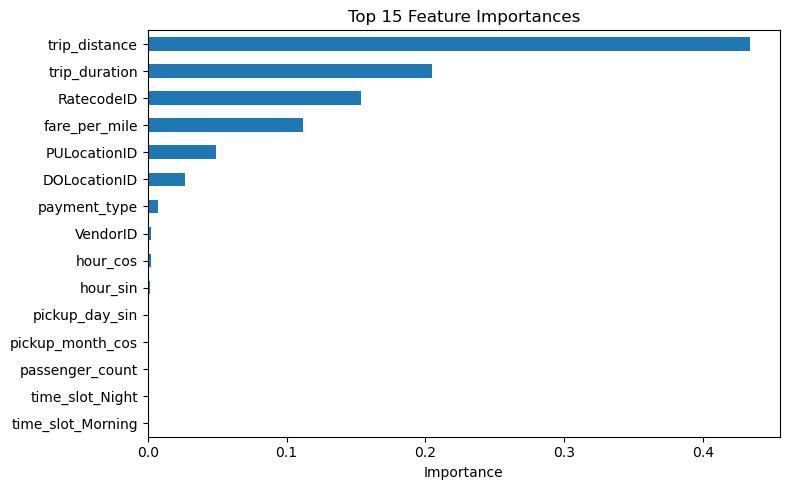

In [40]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)[:15]  # top 15

plt.figure(figsize=(8,5))
importances.plot.barh()
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Residual diagnostics

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.3s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    2.5s finished


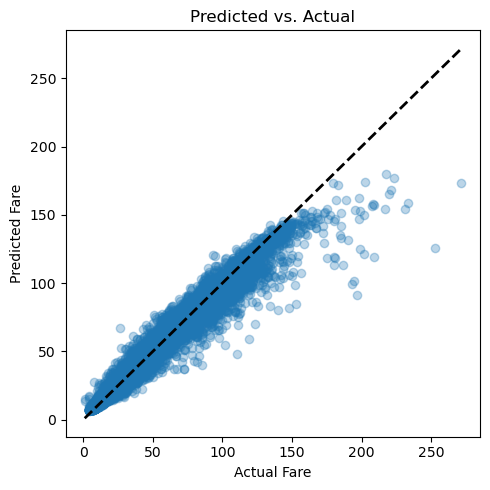

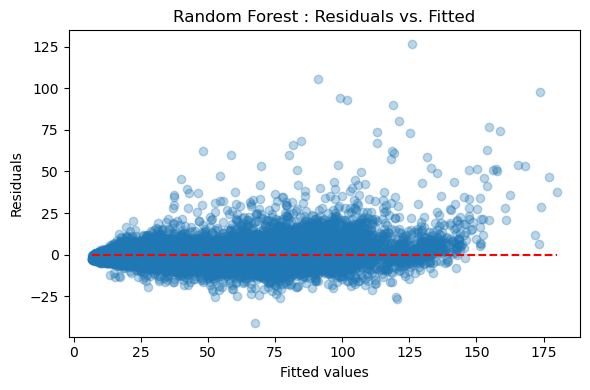

In [41]:
y_pred = rf.predict(X_test)

# 1) Pred vs. actual
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', lw=2)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Predicted vs. Actual")
plt.tight_layout()

# 2) Residuals vs. fitted
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.hlines(0, y_pred.min(), y_pred.max(), colors='r', linestyles='dashed')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Random Forest : Residuals vs. Fitted")
plt.tight_layout()


#### The vertical spread of residuals grows as fitted values increase. In other words, errors are small and tight for low fares, but become larger and more variable for big fares.

#### Great overall fit, especially on the bulk of trips. Struggles on the long tail: the model underestimates very expensive trips and its error variance grows there.

### Shap Explainer

In [48]:
explainer = shap.Explainer(rf, X_train)      # fit once
shap_values = explainer(X_test.iloc[:200])   # limit to 200 rows

shap.plots.bar(shap_values, max_display=15)


### XGBoost

In [45]:
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# fit with an early-stopping callback
xgb_base.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    # eval_metric='rmse',
    # early_stopping_rounds=10,
    verbose=10
)

[0]	validation_0-rmse:18.77360	validation_1-rmse:18.74290
[10]	validation_0-rmse:7.64761	validation_1-rmse:7.64170
[20]	validation_0-rmse:3.80338	validation_1-rmse:3.81380
[30]	validation_0-rmse:2.61981	validation_1-rmse:2.63879
[40]	validation_0-rmse:2.03371	validation_1-rmse:2.05638
[50]	validation_0-rmse:1.77436	validation_1-rmse:1.80117
[60]	validation_0-rmse:1.55488	validation_1-rmse:1.58252
[70]	validation_0-rmse:1.43504	validation_1-rmse:1.46732
[80]	validation_0-rmse:1.32698	validation_1-rmse:1.36384
[90]	validation_0-rmse:1.25520	validation_1-rmse:1.29402
[99]	validation_0-rmse:1.19573	validation_1-rmse:1.23612


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [46]:
y_pred = xgb_base.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"XGB R²: {r2:.4f}")

XGB R²: 0.9964


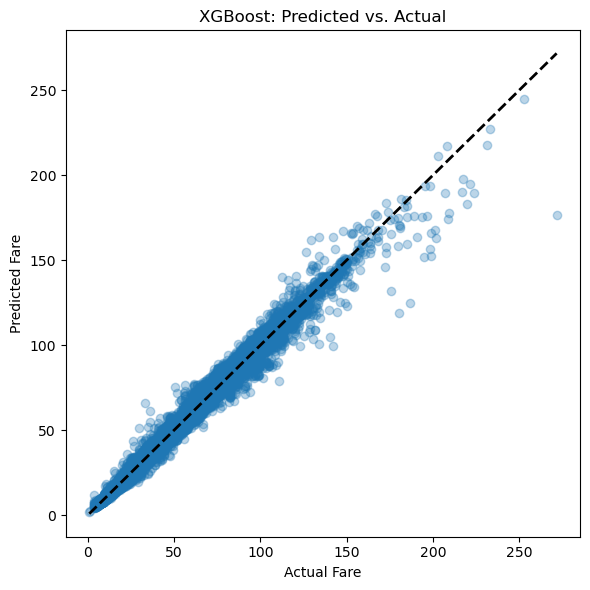

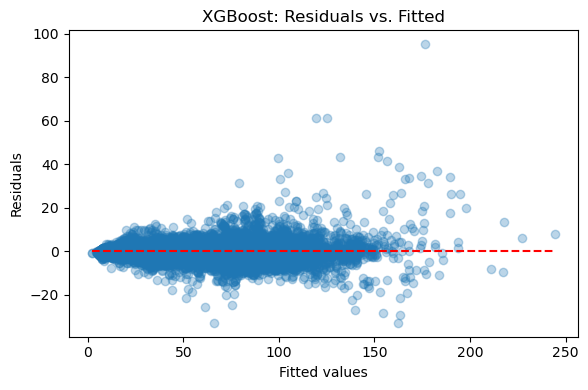

In [47]:
# 1. Get predictions
y_pred_xgb = xgb_base.predict(X_test)

# 2. Predicted vs. Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("XGBoost: Predicted vs. Actual")
plt.tight_layout()
plt.show()

# 3. Residuals vs. Fitted
residuals = y_test - y_pred_xgb
plt.figure(figsize=(6,4))
plt.scatter(y_pred_xgb, residuals, alpha=0.3)
plt.hlines(0, y_pred_xgb.min(), y_pred_xgb.max(),
           colors='r', linestyles='dashed')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("XGBoost: Residuals vs. Fitted")
plt.tight_layout()
plt.show()

In [48]:
# 1. Generate predictions
y_pred = xgb_base.predict(X_test)

# 2. Compute all metrics
r2   = r2_score(y_test,        y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test,  y_pred)
rmse = np.sqrt(mse)

# 3. Print results
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

R²:   0.9964
MAE:  0.6963
MSE:  1.5280
RMSE: 1.2361


### Perform hyperparameter tuning for XGBoost using GridSearchCV
Define an XGBoost model, set up a grid of hyperparameters, perform 3-fold cross-validation, and evaluate the best model on the test set.


In [43]:
# 1. Sample 5% of the original data
X_sub = X.sample(frac=0.05, random_state=42)
y_sub = y.loc[X_sub.index]

# 2. Train/test split on the subsample
X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
    X_sub, y_sub,
    test_size=0.2,
    random_state=42
)

print("X_train_sub:", X_train_sub.shape)
print("X_test_sub: ", X_test_sub.shape)

# 3. Define a smaller grid for XGBoost
param_grid = {
    "n_estimators":      [100, 300],
    "learning_rate":     [0.01, 0.1],
    "max_depth":         [6, 10],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.8, 1.0]
}

# 4. Set up the XGB + GridSearch
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    cv=3,                                # fewer folds for speed
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

# 5. Run grid search
grid_xgb.fit(X_train_sub, y_train_sub)

# 6. Best parameters and CV score
print("Best XGB params:", grid_xgb.best_params_)
print("Best CV RMSE:  ", -grid_xgb.best_score_)

# 7. Evaluate on hold-out test set
best_xgb = grid_xgb.best_estimator_
y_pred = best_xgb.predict(X_test_sub)

# Compute RMSE by hand
mse_test = mean_squared_error(y_test_sub, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test   = r2_score(y_test_sub, y_pred)

print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test R²:   {r2_test:.4f}")

X_train_sub: (47999, 21)
X_test_sub:  (12000, 21)
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinu

Best XGB params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}
Best CV RMSE:   0.9396527351201401
Test RMSE: 1.0986
Test R²:   0.9972
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=1.0; total time=   0.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=300, subsample=0.8; total time=   2.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=300, subsample=0.8; total time=   2.4s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=300, subsample=1.0; total time=   2.3s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=10, n_estimators=100, subsample=0.8; total time=   2

### Analyze cumulative explained variance using PCA
Fit PCA on the training data and display how many principal components are needed to capture most of the dataset's variance.


In [58]:
# Look at cumulative explained variance to choose components
pca_full = PCA().fit(X_train)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
for k, var in enumerate(cum_var[:10], start=1):
    print(f"{k:2d} components → {var*100:5.1f}% variance")

 1 components →  55.0% variance
 2 components →  99.2% variance
 3 components →  99.9% variance
 4 components →  99.9% variance
 5 components →  99.9% variance
 6 components → 100.0% variance
 7 components → 100.0% variance
 8 components → 100.0% variance
 9 components → 100.0% variance
10 components → 100.0% variance


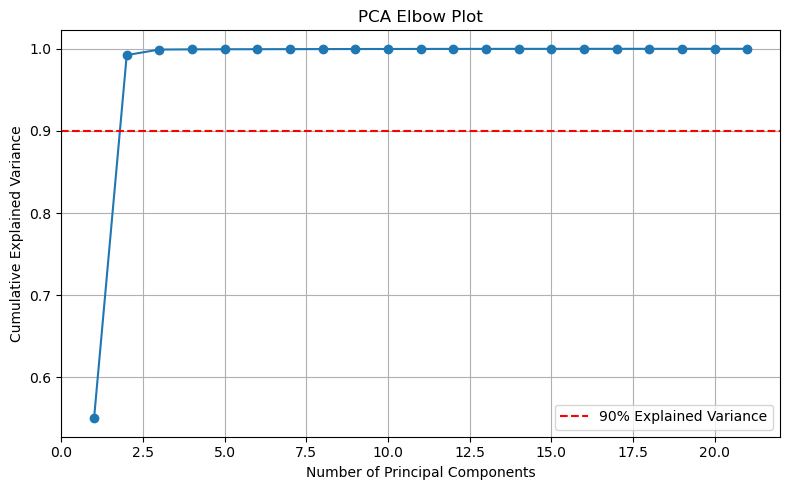

In [56]:
# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Elbow Plot')
plt.grid(True)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

#### The scree plot shows that the first 2–3 principal components capture over 95% of the total variance, indicating strong feature redundancy and allowing for effective dimensionality reduction.


### Apply PCA for dimensionality reduction and retrain XGBoost
Reduce feature space using PCA and train an XGBoost model on the principal components, then evaluate its performance on the test set.


In [68]:
# 1. Fit PCA
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

# 2. Train an XGBoost model on the 6 PCs
xgb_pca = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_pca.fit(X_train_pca, y_train)

# 3. Predict & evaluate
y_pred_xgb_pca = xgb_pca.predict(X_test_pca)
rmse_xgb_pca   = np.sqrt(mean_squared_error(y_test, y_pred_xgb_pca))
r2_xgb_pca     = r2_score(y_test, y_pred_xgb_pca)

print(f"PCA(6) → XGBoost RMSE: {rmse_xgb_pca:.3f}")
print(f"PCA(6) → XGBoost R²:   {r2_xgb_pca:.3f}")

PCA(6) → XGBoost RMSE: 6.416
PCA(6) → XGBoost R²:   0.903


Although dimensionality reduction with PCA to 6 components retained a high R² of **0.903**, the RMSE of **6.416** indicates a noticeable drop in predictive accuracy compared to the full-feature model, highlighting a trade-off between model simplicity and performance.
